# Loan Default Prediction - Exploratory Data Analysis

This notebook performs comprehensive exploratory data analysis (EDA) on the loan default dataset to understand patterns, distributions, and relationships between features and the target variable.

## 1. Import Required Libraries

Import all necessary libraries for data manipulation, numerical computation, and visualization.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Data

Load the raw loan default dataset from the CSV file.

In [52]:
data = pd.read_csv("../data/raw/Loan_default.csv")

## 3. Basic Data Exploration

Understand the structure and characteristics of the dataset.

In [53]:
data.shape

(255347, 18)

In [54]:
data.columns.tolist()

['LoanID',
 'Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [56]:
data.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [57]:
data.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [58]:
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 4. Drop LoanID

Remove the LoanID column as it's just an identifier and not useful for modeling.


In [59]:
data = data.drop("LoanID", axis=1)

## 5. Define X and y

Separate the features (X) and target variable (y) for model training.


In [60]:
X = data.drop("Default", axis=1)
y = data["Default"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (255347, 16)
Shape of y: (255347,)


## 6. Encode Categorical Features

Convert categorical variables to numerical format for model training.


In [61]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Categorical columns:", categorical_cols.tolist())

# Encode categorical variables
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

print("\nEncoding completed. X shape:", X.shape)


Categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Encoding completed. X shape: (255347, 16)


/var/folders/k6/9r87pnwx5tn3zbxvjc1wbgt00000gn/T/ipykernel_10597/145468854.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


## 7. Train-Test Split

Split the data into training and testing sets for model evaluation.


In [62]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Train-test split ratio: 80-20")


Training set size: 204277
Testing set size: 51070
Train-test split ratio: 80-20


## 8. Train Model

Train a machine learning model on the prepared data.


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate the model
print("=== Model Performance ===")
print(f"\nTraining Set Metrics:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")

print(f"\nTesting Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")

print("\nModel training completed successfully!")


=== Model Performance ===

Training Set Metrics:
Accuracy: 0.8849
Precision: 0.5895
Recall: 0.0322
F1-Score: 0.0610

Testing Set Metrics:
Accuracy: 0.8856
Precision: 0.5968
Recall: 0.0314
F1-Score: 0.0596

Model training completed successfully!


/Users/keshavkumar/Documents/Loan Default Prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 9. Evaluate Model

Detailed evaluation of model performance with confusion matrix and classification report.


=== Confusion Matrix ===

Training Set Confusion Matrix:
[[179992    532]
 [ 22989    764]]

Testing Set Confusion Matrix:
[[45045   125]
 [ 5715   185]]

=== Classification Report ===

Training Set:
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94    180524
     Default       0.59      0.03      0.06     23753

    accuracy                           0.88    204277
   macro avg       0.74      0.51      0.50    204277
weighted avg       0.85      0.88      0.84    204277


Testing Set:
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     45170
     Default       0.60      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.74      0.51      0.50     51070
weighted avg       0.85      0.89      0.84     51070



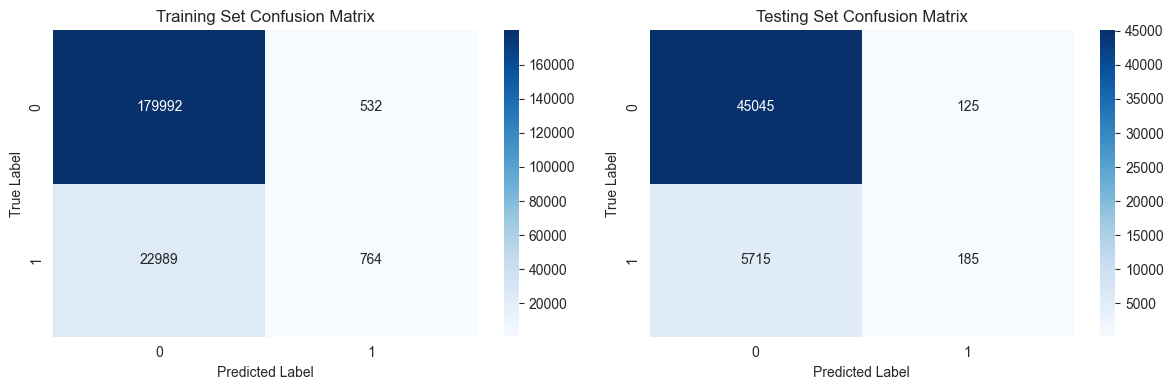


Model evaluation completed!


In [64]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Generate confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("=== Confusion Matrix ===")
print("\nTraining Set Confusion Matrix:")
print(cm_train)
print("\nTesting Set Confusion Matrix:")
print(cm_test)

# Classification report
print("\n=== Classification Report ===")
print("\nTraining Set:")
print(classification_report(y_train, y_train_pred, target_names=['No Default', 'Default']))

print("\nTesting Set:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Testing Set Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\nModel evaluation completed!")


## 10. Additional EDA Visualizations

Explore important patterns and relationships in the data.


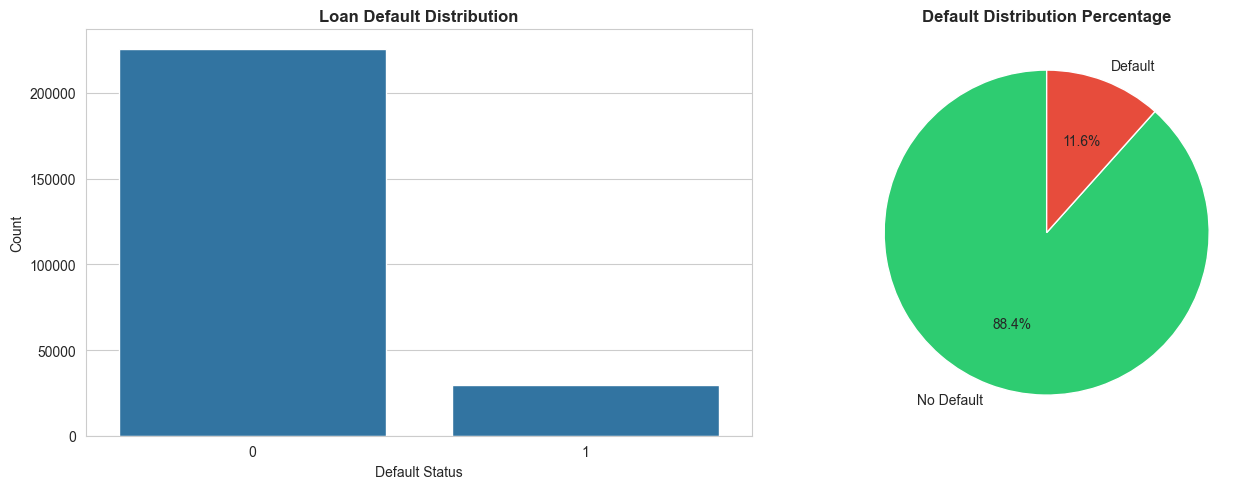

Default Class Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Percentage:
Default
0    88.387175
1    11.612825
Name: count, dtype: float64


In [65]:
### 10.1 Default Class Distribution

# Reload original data for visualizations
data_viz = pd.read_csv("../data/raw/Loan_default.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Default", data=data_viz, ax=axes[0])
axes[0].set_title('Loan Default Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Count')

# Pie chart
default_counts = data_viz['Default'].value_counts()
axes[1].pie(default_counts, labels=['No Default', 'Default'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Default Distribution Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/default_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Default Class Distribution:")
print(default_counts)
print(f"\nPercentage:")
print(default_counts / len(data_viz) * 100)


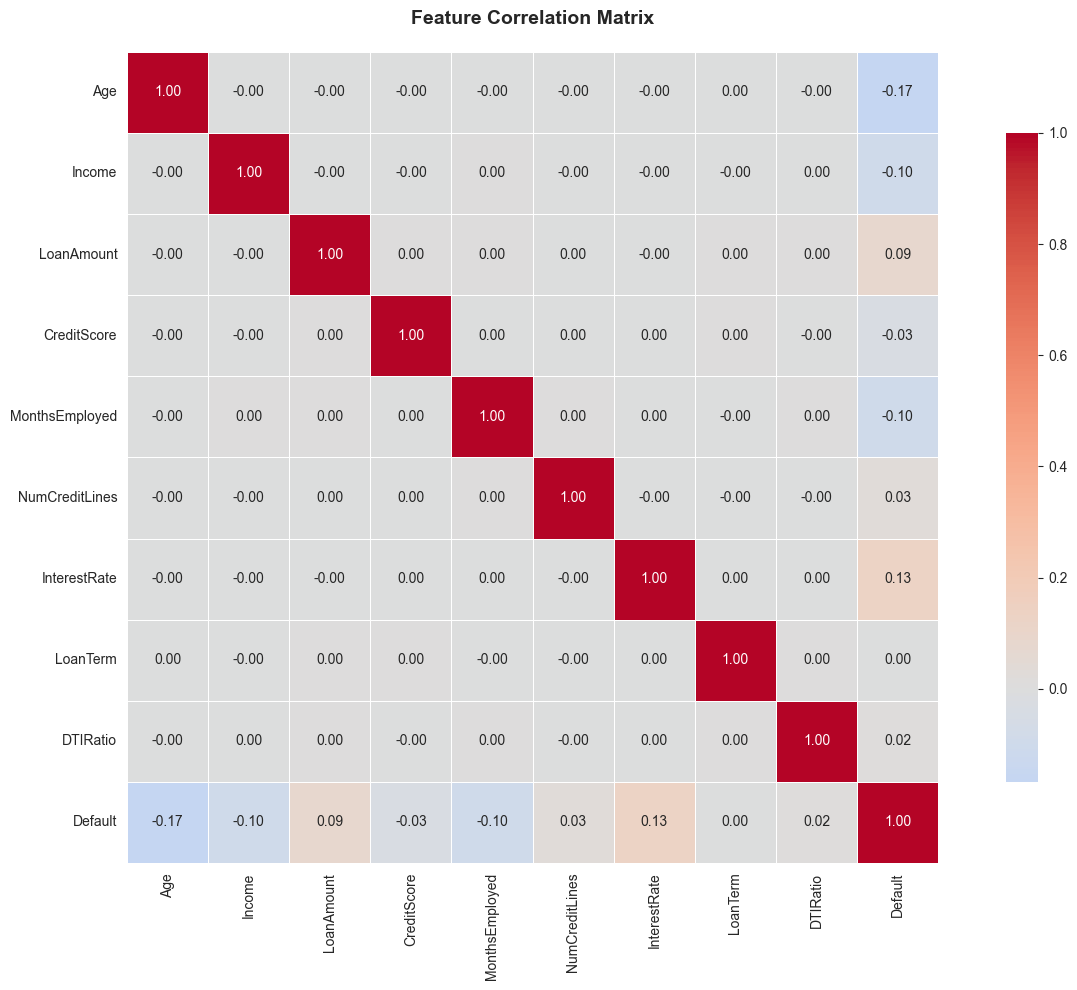

Correlation with Default (Top Features):
Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64


In [66]:
### 10.2 Correlation Heatmap

# Calculate correlation matrix
correlation_matrix = data_viz.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation with Default (Top Features):")
print(correlation_matrix['Default'].sort_values(ascending=False))


/var/folders/k6/9r87pnwx5tn3zbxvjc1wbgt00000gn/T/ipykernel_10597/1509172112.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['No Default', 'Default'])
/var/folders/k6/9r87pnwx5tn3zbxvjc1wbgt00000gn/T/ipykernel_10597/1509172112.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['No Default', 'Default'])


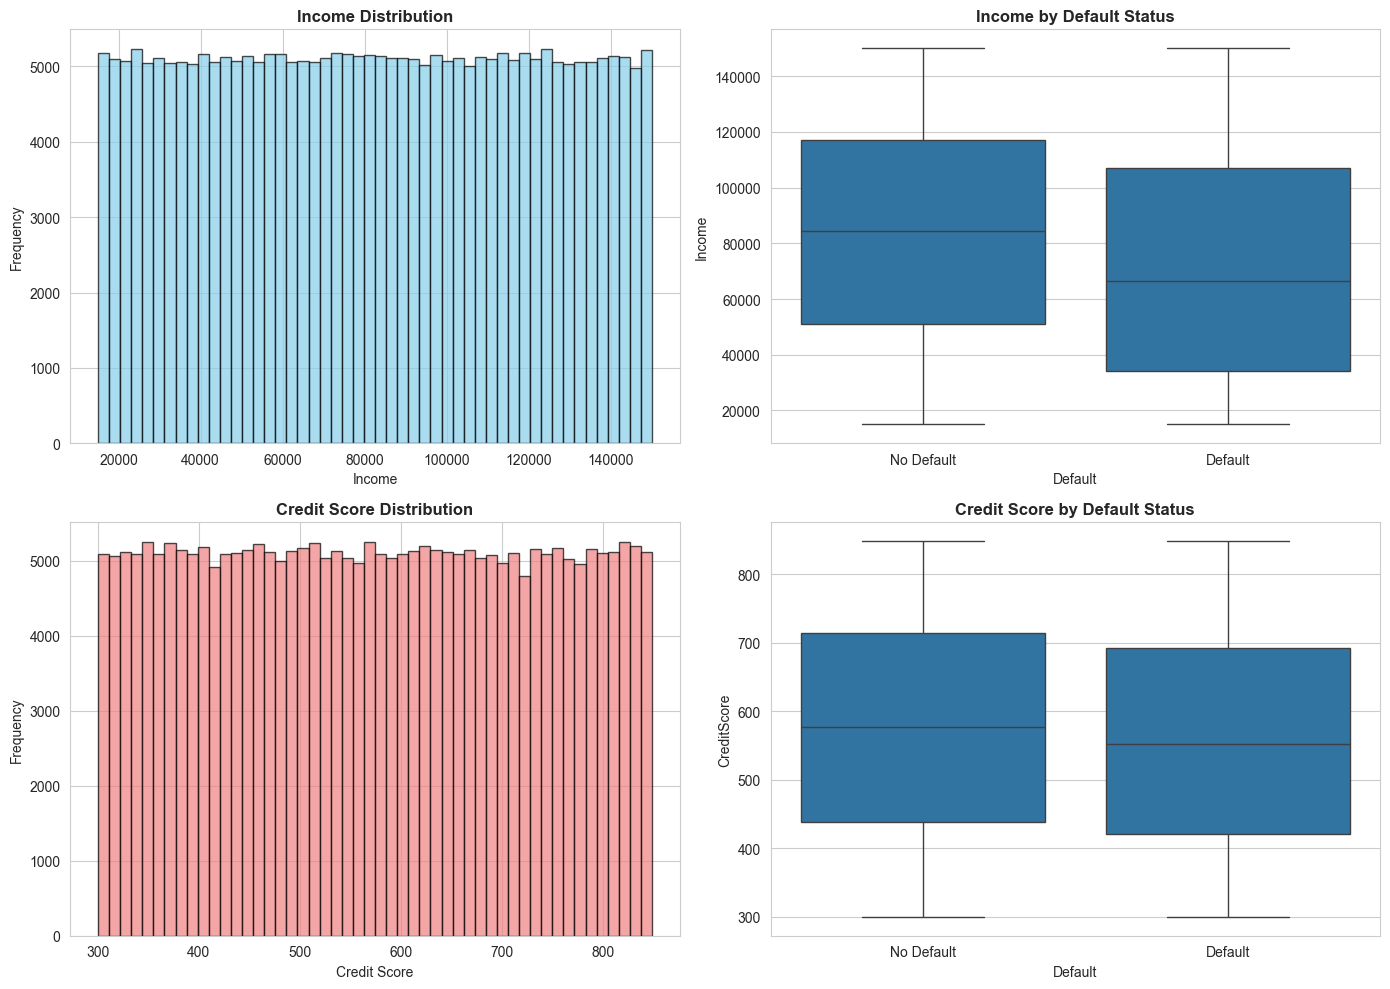

Income Statistics:
Mean: $82499.30
Median: $82466.00

Credit Score Statistics:
Mean: 574.26
Median: 574.00


In [67]:
### 10.3 Income and Credit Score Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income distribution
axes[0, 0].hist(data_viz['Income'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Income Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Income')
axes[0, 0].set_ylabel('Frequency')

# Income vs Default (boxplot)
sns.boxplot(x='Default', y='Income', data=data_viz, ax=axes[0, 1])
axes[0, 1].set_title('Income by Default Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['No Default', 'Default'])

# Credit Score distribution
axes[1, 0].hist(data_viz['CreditScore'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Credit Score Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Credit Score')
axes[1, 0].set_ylabel('Frequency')

# Credit Score vs Default (boxplot)
sns.boxplot(x='Default', y='CreditScore', data=data_viz, ax=axes[1, 1])
axes[1, 1].set_title('Credit Score by Default Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.savefig('../outputs/figures/income_credit_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Income Statistics:")
print(f"Mean: ${data_viz['Income'].mean():.2f}")
print(f"Median: ${data_viz['Income'].median():.2f}")
print(f"\nCredit Score Statistics:")
print(f"Mean: {data_viz['CreditScore'].mean():.2f}")
print(f"Median: {data_viz['CreditScore'].median():.2f}")


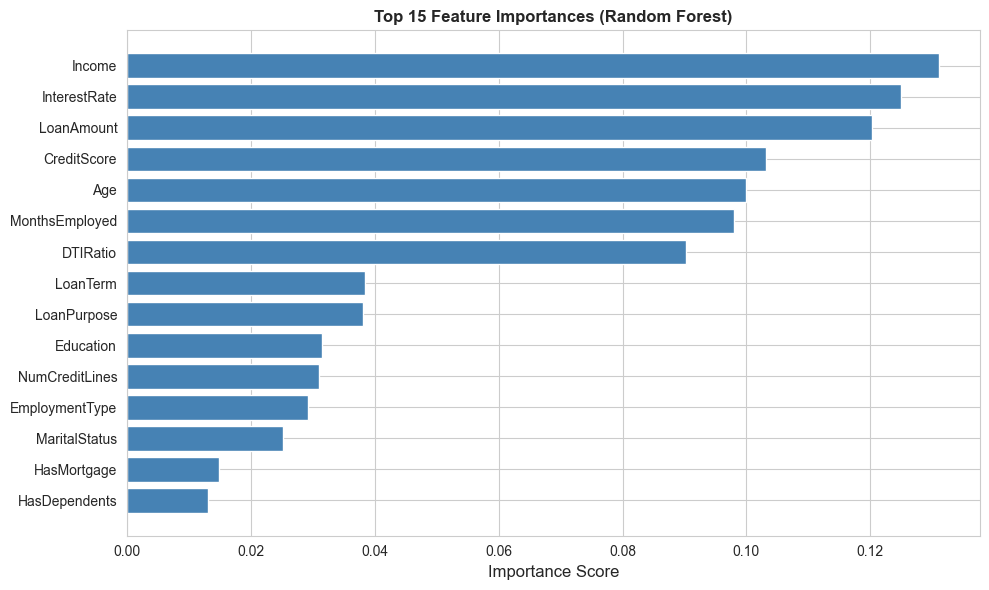

Top 15 Most Important Features:
       feature  importance
        Income    0.131150
  InterestRate    0.124973
    LoanAmount    0.120314
   CreditScore    0.103102
           Age    0.100010
MonthsEmployed    0.097976
      DTIRatio    0.090211
      LoanTerm    0.038477
   LoanPurpose    0.038152
     Education    0.031509
NumCreditLines    0.030943
EmploymentType    0.029285
 MaritalStatus    0.025122
   HasMortgage    0.014929
 HasDependents    0.013157


In [68]:
### 10.4 Feature Importance Analysis

# Get feature importances from Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Prepare data for feature importance
X_features = X.copy()
feature_names = X.columns.tolist()

# Train a quick Random Forest to assess feature importance
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train, y_train)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
top_n = 15
top_features = feature_importance.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))
